In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
from Tools.data_utils import SimulationData, lorenz_stochastic
from Tools.mathematical_tools import denormalize_columns, normalize_columns, diagonal_mean
from Tools.analysis_tools import reconstruct_signal_from_embedding

In [14]:
# Parametri simulazione
n_steps = 10000
dt = 0.01
alpha = 0
beta = 0

# Parametri embedding
tau = 15
embedding_dim = 20
legendre_dim= 10

p_eff = (n_steps- embedding_dim*tau)/tau +1 # (p - d) + 1 nel paper
print("p_eff from this embedding parameters: ", int(p_eff))

# Crea una nuova istanza
simulation = SimulationData(n_steps, dt, alpha, beta, tau, embedding_dim, legendre_dim)

# Esegui la simulazione
simulation.run_simulation(lorenz_stochastic)

# Genera le osservabili
simulation.generate_observables()

# Normalizza le serie temporali degli osservabili
#simulation.normalize_data() # Normalizzazione più avanti

# Crea gli embedding delle osservabili
simulation.create_embeddings()

# Crea le Matrici di Hankel
simulation.create_Hankel_Matrices() 

# Proietta sulla base di polinomi di Legendre
simulation.project_on_legendre()  # Matrice dimensione r x (p+d)-1

#Save matrix for decompression analysis
before = simulation.projected_H1

# Normalization of Neural Network input
simulation.normalize_legendreProjection()


print("y1 shape: ", simulation.y1.shape)
print("y2 shape: ", simulation.y2.shape)
print("y1_embedding shape: ", simulation.y1_embedding.shape)
print("y2_embedding_1 shape: ", simulation.y2_embedding_1.shape)
print("y2_embedding_2 shape: ", simulation.y2_embedding_2.shape)
print("Hankel shape: ", simulation.H1.shape)
print("Projected Hankel shape: ", simulation.projected_H1.shape)
print("Legendre Basis Matrix Shape: ", simulation.P.shape)



p_eff from this embedding parameters:  647
y1 shape:  (10000,)
y2 shape:  (10000, 2)
y1_embedding shape:  (9715, 20)
y2_embedding_1 shape:  (9715, 20)
y2_embedding_2 shape:  (9715, 20)
Hankel shape:  (20, 648)
Projected Hankel shape:  (10, 648)
Legendre Basis Matrix Shape:  (20, 10)


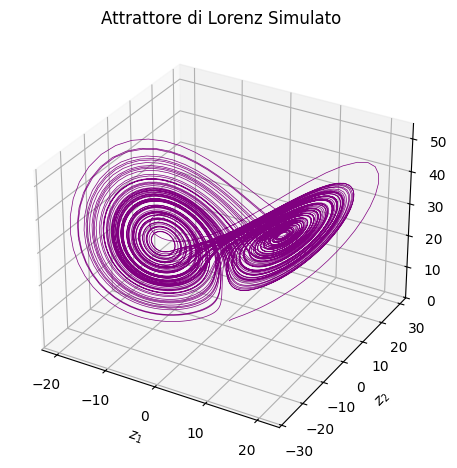

In [15]:
# Grafico delle traiettorie 
fig = plt.figure(figsize=(12, 6))
# Primo subplot
ax = fig.add_subplot(121, projection="3d")
ax.plot(simulation.trajectory[:, 0], simulation.trajectory[:, 1], simulation.trajectory[:, 2], color='purple', lw=0.5)
ax.set_title("Attrattore di Lorenz Simulato")
ax.set_xlabel(f"$z_1$")
ax.set_ylabel(f"$z_2$")
ax.set_zlabel(f"$z_3$")
plt.show()


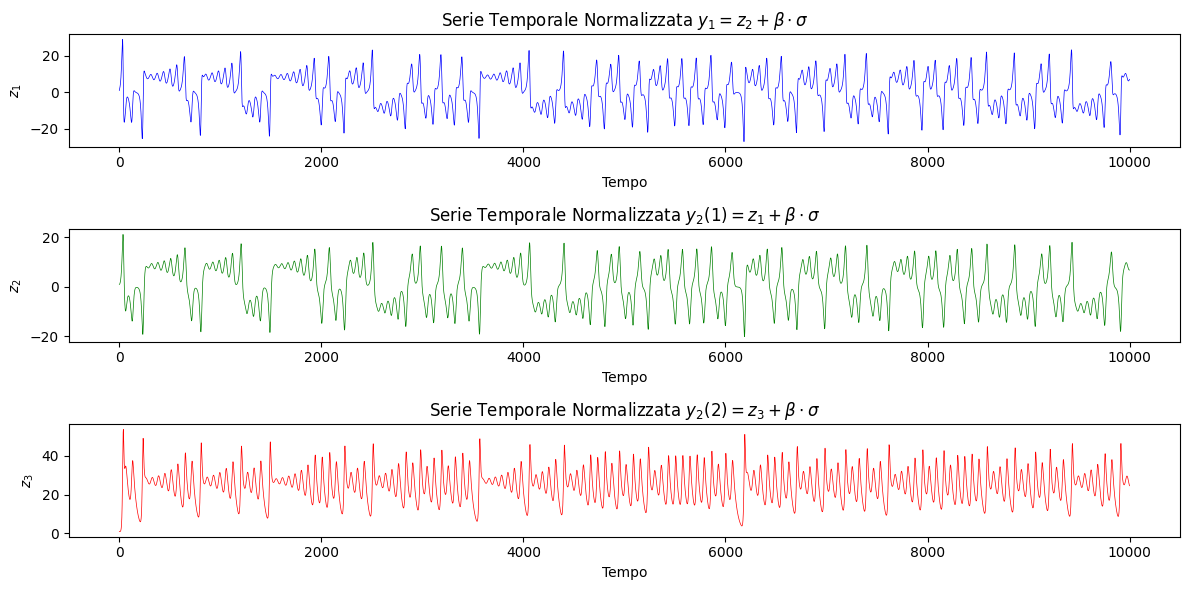

In [16]:
# Grafico delle serie temporali
fig = plt.figure(figsize=(12, 6))
# Primo subplot
ax1 = fig.add_subplot(311)
ax1.plot(simulation.y1, color='blue', lw=0.5)
ax1.set_title(r"Serie Temporale Normalizzata $y_1 = z_2 + \beta \cdot \sigma$")
ax1.set_xlabel("Tempo")
ax1.set_ylabel("$z_1$")

ax2 = fig.add_subplot(312)
ax2.plot(simulation.y2[:,0], color='green', lw=0.5)
ax2.set_title(r"Serie Temporale Normalizzata $y_2(1) = z_1 + \beta \cdot \sigma$")
ax2.set_xlabel("Tempo")
ax2.set_ylabel("$z_2$")

ax3 = fig.add_subplot(313)
ax3.plot(simulation.y2[:,1], color='red', lw=0.5)
ax3.set_title(r"Serie Temporale Normalizzata $y_2(2) = z_3 + \beta \cdot \sigma$")
ax3.set_xlabel("Tempo")
ax3.set_ylabel("$z_3$")

plt.tight_layout()
plt.show()

### Signal reconstruction test:

Testing methods to reconstruct the original data from the compressed (low dimensional) representation.

#### 1- Least Squares Method

Difference between before and after normalization:  1.2980880259583216e-11
Difference between original and decompressed Hankel (least squares):  36531.89917820503


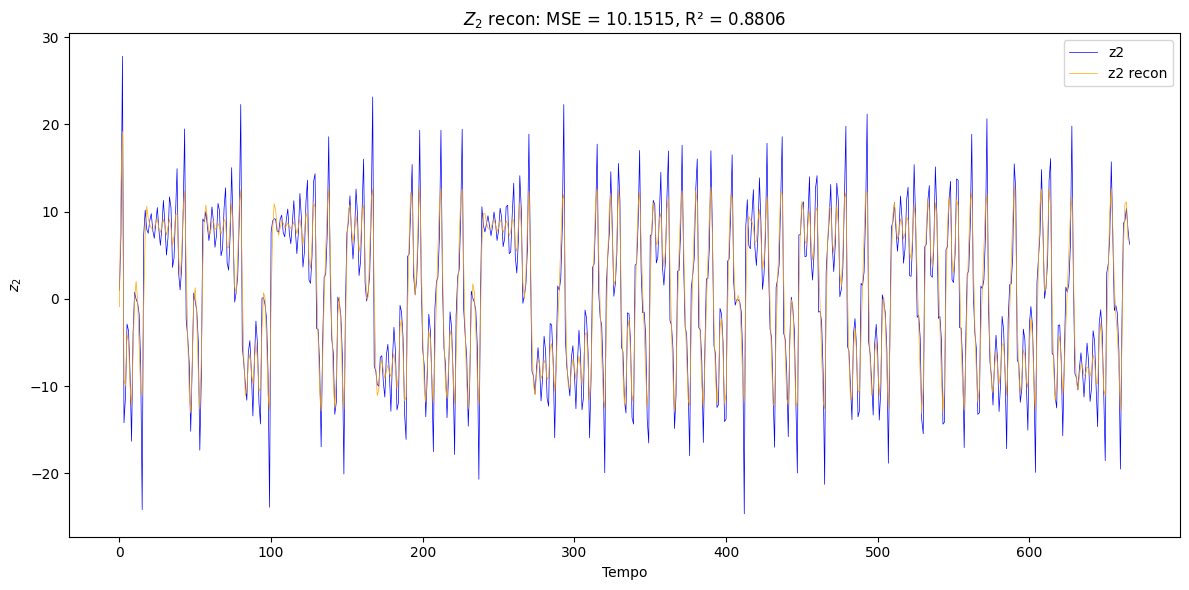

In [17]:
import numpy as np
from scipy.linalg import lstsq

# Original Hankel matrix
original_input_H1 = simulation.H1 #This is not modified by normalization

# Denormalization check
after = denormalize_columns(simulation.projected_H1, simulation.min_h1, simulation.max_h1)

# Test difference between before and after normalization
diff = np.sum(np.abs(before - after))
print("Difference between before and after normalization: ", diff)

# Testing decompression using least squares
decompr_H1 = np.zeros((simulation.P.shape[0], after.shape[1]))  # Shape: (d, n_colonne)
for i in range(after.shape[1]):
    # Risolvi il sistema trasposto
    decompr_H1[:, i], _, _, _ = lstsq(simulation.P.T, after[:, i])

# Test difference between original and decompressed Hankel
diffDeco = np.sum(np.abs(original_input_H1 - decompr_H1))
print("Difference between original and decompressed Hankel (least squares): ", diffDeco)

original_signal = diagonal_mean(original_input_H1)
decompressed_signal = diagonal_mean(decompr_H1)

# Calculate MSE and R²
mse1 = np.mean((original_signal - decompressed_signal) ** 2)
r2_1 = 1 - np.sum((original_signal - decompressed_signal) ** 2) / np.sum((original_signal - np.mean(original_signal)) ** 2)

# Plot dei segnali
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(original_signal, label="z2", color='blue', lw=0.5)
ax.plot(decompressed_signal, label="z2 recon", color='orange', lw=0.5)
ax.legend()
ax.set_title(r"$Z_2$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse1, r2_1))
ax.set_xlabel("Tempo")
ax.set_ylabel("$z_2$")

plt.tight_layout()
plt.show()


#### 2- Pseudo inverse Matrix of $P^{(r)}$ :

Difference between original and decompressed Hankel (least squares):  36531.89917820503


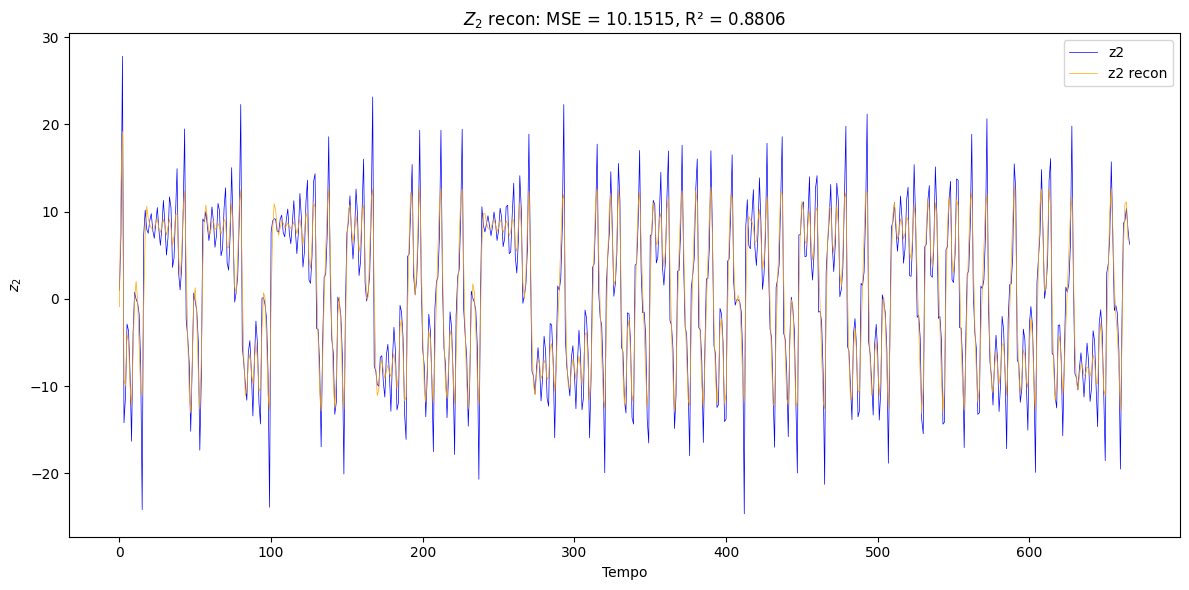

In [20]:
from numpy.linalg import pinv

# Calcola la pseudo-inversa di P
P_pseudo_inverse = pinv(simulation.P)

decompr_H1 = np.dot(P_pseudo_inverse.T, after)

# Test difference between original and decompressed Hankel
diffDeco = np.sum(np.abs(original_input_H1 - decompr_H1))
print("Difference between original and decompressed Hankel (least squares): ", diffDeco)

original_signal = diagonal_mean(original_input_H1)
decompressed_signal = diagonal_mean(decompr_H1)

# Calculate MSE and R²
mse1 = np.mean((original_signal - decompressed_signal) ** 2)
r2_1 = 1 - np.sum((original_signal - decompressed_signal) ** 2) / np.sum((original_signal - np.mean(original_signal)) ** 2)

# Plot dei segnali
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(original_signal, label="z2", color='blue', lw=0.5)
ax.plot(decompressed_signal, label="z2 recon", color='orange', lw=0.5)
ax.legend()
ax.set_title(r"$Z_2$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse1, r2_1))
ax.set_xlabel("Tempo")
ax.set_ylabel("$z_2$")

plt.tight_layout()
plt.show()


In [19]:
sim_name = simulation.generate_filename()
output_folder = "Simulation data"

file_path = os.path.join(output_folder, sim_name)
print(file_path)

simulation.save_to_file(file_path)
print("Simulation data saved to file")


Simulation data/delay15dim20,10_noise0,0.json


Simulation data saved to file
